## Imports

In [1]:
import random
import torch
from torch import nn
from torch.amp import GradScaler
from torch.utils.data import Dataset, DataLoader
from torch.utils.tensorboard import SummaryWriter
from tqdm import tqdm
from sklearn import preprocessing
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from matplotlib import colormaps
import pandas as pd

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

scaler = GradScaler(device=device)

# for mapping labels
label_encoder = preprocessing.LabelEncoder()

Using device: cuda


## constants

In [2]:
# CONSTANTS --------------------------------------------------------------------------

phone_map = {'aa': 0, 'ae': 1, 'ah': 2, 'ao': 3, 'aw': 4, 'ax': 5, 'ax-h': 6, 'axr': 7, 
'ay': 8, 'b': 9, 'bcl': 10, 'ch': 11, 'd': 12, 'dcl': 13, 'dh': 14, 'dx': 15, 
'eh': 16, 'el': 17, 'em': 18, 'en': 19, 'eng': 20, 'epi': 21, 'er': 22, 'ey': 23, 
'f': 24, 'g': 25, 'gcl': 26, 'h#': 27, 'hh': 28, 'hv': 29, 'ih': 30, 'ix': 31, 
'iy': 32, 'jh': 33, 'k': 34, 'kcl': 35, 'l': 36, 'm': 37, 'n': 38, 'ng': 39, 
'nx': 40, 'ow': 41, 'oy': 42, 'p': 43, 'pau': 44, 'pcl': 45, 'q': 46, 'r': 47, 
's': 48, 'sh': 49, 't': 50, 'tcl': 51, 'th': 52, 'uh': 53, 'uw': 54, 'ux': 55, 
'v': 56, 'w': 57, 'y': 58, 'z': 59, 'zh': 60}

# from TIMIT PHONCODE.DOC
moa_map = {
    'stop': {'b', 'd', 'g', 'p', 't', 'k', 'dx', 'q'},
    'affricate': {'jh', 'ch'},
    'fricative': {'s', 'sh', 'z', 'zh', 'f', 'th', 'v', 'dh'},
    'nasal': {'m', 'n', 'ng', 'em', 'en', 'eng', 'nx'},
    'approximant': {'l', 'r', 'w', 'y', 'hh', 'hv', 'el'},
    'vowel': {'iy', 'ih', 'eh', 'ey', 'ae', 'aa', 'aw', 'ay', 'ah', 'ao', 'oy', 'ow', 'uh', 'uw', 'ux', 'er', 'ax', 'ix', 'axr', 'ax-h'},
    'none': {'h#', 'pau', 'epi', '1', '2'}
}

voiced_map = {
    'voiced': {'b', 'd', 'g', 'dx', 'jh', 'z', 'zh', 'v', 'dh', 'm', 'n', 'ng', 'em', 'en', 'eng', 'nx', 'l', 'r', 'w', 'y', 'el', 'iy', 'ih', 'eh', 'ey', 'ae', 'aa', 'aw', 'ay', 'ah', 'ao', 'oy', 'ow', 'uh', 'uw', 'ux', 'er', 'ax', 'ix', 'axr', 'ax-h'},
    'unvoiced': {'p', 't', 'k', 'q', 'ch', 's', 'sh', 'f', 'th', 'hh', 'hv'}
}

# vowel_height_map = {
#     'high': {'iy', 'ih', 'ey', 'uh','uw','ux','ix'},
#     'mid': {'eh', 'ae', 'ah', 'ao', 'er', 'ax', 'axr', 'ax-h'},
#     'low': {'aa', },
#     'diphthong': {'aw', 'ay', 'oy', 'ow'}
# }

# invert the map so we can convert from phones to manner of articulation
phone_to_moa_map = {}
for moa, phone_set in moa_map.items():
    for phone in phone_set:
        phone_to_moa_map[phone] = moa

def phone_to_moa(phone):
    if phone in phone_to_moa_map.keys():
        return phone_to_moa_map[phone]
    return 'none'

# invert the map so we can convert from phones to voicedness
phone_to_voiced_map = {}
for voicedness, phone_set in moa_map.items():
    for phone in phone_set:
        phone_to_voiced_map[phone] = voicedness

def phone_to_voiced(phone):
    if phone in phone_to_voiced_map.keys():
        return phone_to_voiced_map[phone]
    return 'none'

### dataset and probe definitions

In [3]:
# dataset definition
class AudioDataset(Dataset):
    def __init__(self, x, y):
        self.x         = x
        self.y         = y

    def __getitem__(self, index):
        return self.x[index], self.y[index]

    def __len__(self):
        return len(self.x)

# define probe architecture
class ProbeNet(nn.Module):
    def __init__(self, embedding_dim, encoder="", encoderLayer=""):
        super(ProbeNet, self).__init__()

        self.encoder = encoder
        self.encoderLayer = encoderLayer

        self.layers = nn.Sequential(
            nn.Linear(embedding_dim, 200),
            nn.ReLU(),
            # nn.Dropout(0.2),
            # nn.Linear(200, 61) # 61 phones
            nn.Linear(200, 6) # 6 manners of articulation
        )
    
    def forward(self, x):
        x = self.layers(x)
        return x

## helper functions

In [4]:
def data_setup(embeddings, labels):
    # go from raw phones to MOA labels
    labels = list(map(phone_to_moa, labels))

    # filter out none values
    new_embeddings = []
    new_labels = []

    for i in range(len(labels)):
        if labels[i] != 'none':
            new_embeddings.append(embeddings[i])
            new_labels.append(labels[i])

    # convert our phone labels into integers so we can fit to them
    labels_types = label_encoder.fit_transform(new_labels)

    print("records: " + str(len(new_embeddings)))

    train_set = AudioDataset(new_embeddings, labels_types)

    train_loader = DataLoader(
        dataset=train_set,
        batch_size=128,
        shuffle=True,
        num_workers=0
    )

    print('batches: ' + str(len(train_loader)))

    return train_loader

def train(probe, loader, writer, epochs, criterion, optimizer, note):
    for epoch in tqdm(range(1, epochs + 1),
            "Training " + probe.encoder + " layer " + probe.encoderLayer,
            epochs
    ):
        probe.train()

        correct = 0
        total = 0

        # for data in tqdm(train_loader, desc="Training", total=len(train_loader)):
        for data in loader:
            inputs = data[0].to(device).float()
            targets = data[1].to(device)

            outputs = probe(inputs)

            loss = criterion(outputs, targets)

            optimizer.zero_grad()
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            predicted = torch.argmax(outputs, dim=1)
            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()
        
        accuracy = 100.*correct / total
        writer.add_scalar(note, accuracy, epoch)

def test(probe, loader, writer):
    labels_for_confusion = []
    predictions_for_confusion = []

    total = 0
    correct = 0

    for data in tqdm(
        loader,
        "Testing" + probe.encoder + " layer " + probe.encoderLayer,
        len(loader)
    ):
        inputs = data[0].to(device).float()
        targets = data[1].to(device)

        outputs = probe(inputs)

        predicted = torch.argmax(outputs, dim=1)
        total += predicted.size(0)
        correct += predicted.eq(targets).sum().item()

        cpu_target = targets.cpu()
        cpu_predicted = predicted.cpu()
        
        moa_targets = label_encoder.inverse_transform(cpu_target)
        moa_predicted = label_encoder.inverse_transform(cpu_predicted)

        labels_for_confusion.extend(moa_targets)
        predictions_for_confusion.extend(moa_predicted)
        
    accuracy = 100.*correct/total
    writer.add_scalar(probe.encoder + probe.encoderLayer + ' test accuracy', accuracy)

    results_df = pd.DataFrame({
        "true_label": labels_for_confusion,
        "predicted_label": predictions_for_confusion
        })

    print("writing to" + "predictions/" + probe.encoder + "-layer" + probe.encoderLayer + ".csv")

    results_df.to_csv(
        "predictions/" + probe.encoder + "-layer" + probe.encoderLayer + ".csv",
        index=False
    )

def createConfusionFigure(encoder, encoderLayer):
    results_df = pd.read_csv("predictions/" + encoder + "-layer" + encoderLayer + ".csv")

    table_data = []

    for class_name in label_encoder.classes_:
        class_rows = results_df["true_label"] == class_name
        correct = results_df.loc[class_rows, "predicted_label"] == class_name

        class_accuracy = 100 * correct.sum() / class_rows.sum()
        table_data.append([class_name, f"{class_accuracy:.4f}%"])

    labels_for_confusion = results_df["true_label"].tolist()
    predictions_for_confusion = results_df["predicted_label"].tolist()

    fig, ax = plt.subplots(figsize=(10, 7))
    cm = confusion_matrix(labels_for_confusion, predictions_for_confusion, labels=label_encoder.classes_, normalize="true")

    ConfusionMatrixDisplay(cm, display_labels=label_encoder.classes_).plot(ax=ax)
    plt.title("Whisper Embedding Manner of Articulation Confusion Matrix")

    ax_table = fig.add_axes([0.85, 0.4, 0.20, 0.4])  # [left, bottom, width, height]
    ax_table.axis('off')
    table = ax_table.table(
        cellText=table_data,
        colLabels=['Class', 'Accuracy'],
        loc='center',
        cellLoc='center'
    )
    table.scale(1, 2)

    plt.savefig('figures/' + encoder + "-layer" + encoderLayer + 'MOAconfusion.png', dpi=300, bbox_inches='tight')

## Whisper
----

### train whisper encoder

In [5]:
# load whisper train embeddings
print("Loading saved whisper embeddings...")
whisper_train_embeddings = torch.load('data/saved_embeddings/whisper_train_embeddings.pt')
whisper_train_labels = torch.load('data/saved_embeddings/whisper_train_labels.pt')

print("Remapping + batching saved whisper embeddings....")
whisper_train_loader = data_setup(whisper_train_embeddings, whisper_train_labels)

# set up whisper probe
whisper_probe = ProbeNet(768, "whisper", "final").to(device)
optimizer = torch.optim.Adam(whisper_probe.parameters())
criterion = nn.CrossEntropyLoss()

# data-setup sets up the label encoder that we will reuse
torch.save(label_encoder, 'label_encoders/moa_label_encoder.pt')

# train + save whisper probe
writer = SummaryWriter(comment='whisper moa probe')
train(whisper_probe, whisper_train_loader, writer, 50, criterion, optimizer, 'whisper moa probe accuracy')

torch.save(whisper_probe, 'models/' + whisper_probe.encoder + '-layer' + whisper_probe.encoderLayer + '.pth')

# clear data that we're done with
del whisper_train_embeddings
del whisper_train_loader
del whisper_train_labels

Loading saved whisper embeddings...
Remapping + batching saved whisper embeddings....
records: 128721
batches: 1006


Training whisper layer final: 100%|██████████| 50/50 [01:11<00:00,  1.43s/it]


### test probe + display confusion matrix

Loading saved test whisper embeddings...
Remapping + batching saved test whisper embeddings....
records: 47013
batches: 368


Testingwhisper layer final: 100%|██████████| 368/368 [00:00<00:00, 854.51it/s]


writing topredictions/whisper-layerfinal.csv


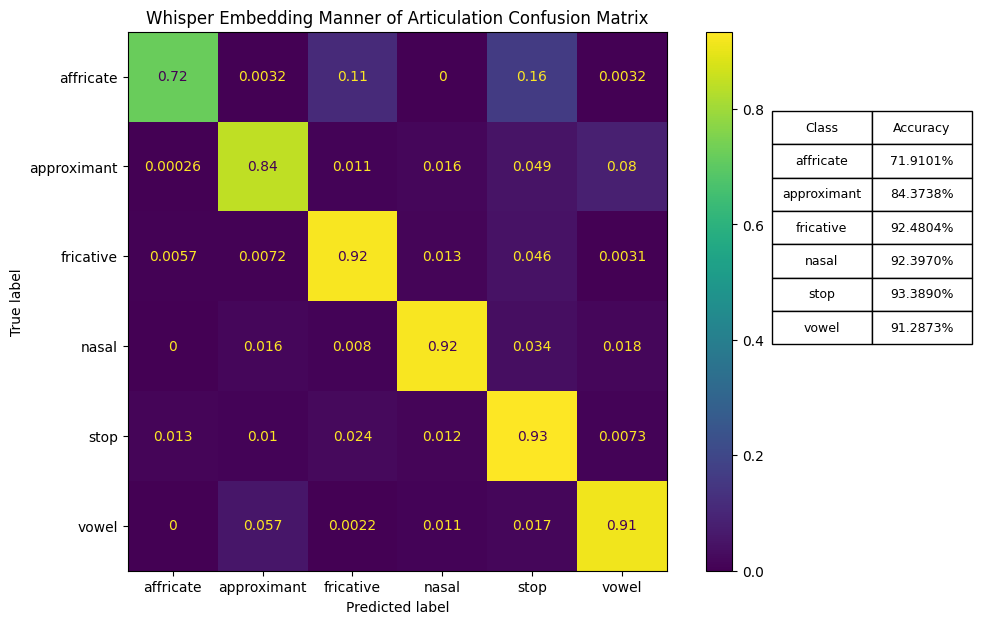

In [6]:
# whisper MOA test
print("Loading saved test whisper embeddings...")
whisper_test_embeddings = torch.load('data/saved_embeddings/whisper_test_embeddings.pt')
whisper_test_labels = torch.load('data/saved_embeddings/whisper_test_labels.pt')

print("Remapping + batching saved test whisper embeddings....")
whisper_test_loader = data_setup(whisper_test_embeddings, whisper_test_labels)

writer = SummaryWriter(comment='whisper moa probe')
label_encoder = torch.load('label_encoders/moa_label_encoder.pt', weights_only=False)
# whisper_probe = torch.load('models/whisper_moa_probe.pth', weights_only=False)

whisper_probe.eval()
test(whisper_probe, whisper_test_loader, writer)

createConfusionFigure("whisper", "final")

## wav2vec
---
### train wav2vec

In [ ]:
# initialize and train the wav2vec probe
print("Loading saved wav2vec embeddings...")
wav2vec_train_embeddings = torch.load('data/saved_embeddings/wav2vec_train_embeddings.pt')
wav2vec_train_labels = torch.load('data/saved_embeddings/wav2vec_train_labels.pt')

print("Remapping + batching saved wav2vec embeddings....")
wav2vec_train_loader = data_setup(wav2vec_train_embeddings, wav2vec_train_labels)

wav2vec_probe = ProbeNet(768, "wav2vec", "final").to(device)
optimizer = torch.optim.Adam(wav2vec_probe.parameters())
criterion = nn.CrossEntropyLoss()

writer = SummaryWriter(comment='wav2vec probe')
train(wav2vec_probe, wav2vec_train_loader, writer, 50, criterion, optimizer, 'wav2vec moa probe accuracy')

torch.save(wav2vec_probe, 'models/' + wav2vec_probe.encoder + '-layer' + wav2vec_probe.encoderLayer + '.pth')


# clear data that we're done with
del wav2vec_train_embeddings
del wav2vec_train_loader
del wav2vec_train_labels

Loading saved wav2vec embeddings...
Remapping + batching saved wav2vec embeddings....
records: 128721
batches: 1006


Training  layer : 100%|██████████| 50/50 [01:21<00:00,  1.62s/it]


### test wav2vec + display confusion matrix

In [10]:
# test wav2vec MOA probe
print("Loading saved test wav2vec embeddings...")
wav2vec_test_embeddings = torch.load('data/saved_embeddings/wav2vec_test_embeddings.pt')
wav2vec_test_labels = torch.load('data/saved_embeddings/wav2vec_test_labels.pt')

print("Remapping + batching saved test wav2vec embeddings....")
wav2vec_test_loader = data_setup(wav2vec_test_embeddings, wav2vec_test_labels)

writer = SummaryWriter(comment='wav2vec moa probe')
label_encoder = torch.load('label_encoders/moa_label_encoder.pt', weights_only=False)
# wav2vec_probe = torch.load('models/wav2vec_moa_probe.pth', weights_only=False)

wav2vec_probe.eval()

test(wav2vec_probe, wav2vec_test_loader, writer)

createConfusionFigure("wav2vec", "final")

Loading saved test wav2vec embeddings...
Remapping + batching saved test wav2vec embeddings....
records: 47013
batches: 368


Testing layer : 100%|██████████| 368/368 [00:00<00:00, 955.93it/s]

writing topredictions/-layer.csv


FileNotFoundError: [Errno 2] No such file or directory: 'predictions/wav2vec-layerfinal.csv'

## voxtral
---
### train

In [ ]:
# initialize and train the voxtral probe
print("Loading saved voxtral embeddings...")
voxtral_train_embeddings = torch.load('data/saved_embeddings/voxtral_train_embeddings.pt')
voxtral_train_labels = torch.load('data/saved_embeddings/voxtral_train_labels.pt')

print("Remapping + batching saved voxtral embeddings....")
voxtral_train_loader = data_setup(voxtral_train_embeddings, voxtral_train_labels)

voxtral_probe = ProbeNet(1280, "voxtral", "final").to(device)
optimizer = torch.optim.Adam(voxtral_probe.parameters())
criterion = nn.CrossEntropyLoss()

writer = SummaryWriter(comment='voxtral probe')
train(voxtral_probe, voxtral_train_loader, writer, 50, criterion, optimizer, 'voxtral moa probe accuracy')

torch.save(voxtral_probe, 'models/' + voxtral_probe.encoder + '-layer' + voxtral_probe.encoderLayer + '.pth')

# clear data that we're done with
del voxtral_train_embeddings
del voxtral_train_loader
del voxtral_train_labels

### test + confusion matrix

In [ ]:
# voxtral MOA test
print("Loading saved test voxtral embeddings...")
voxtral_test_embeddings = torch.load('data/saved_embeddings/voxtral_test_embeddings.pt')
voxtral_test_labels = torch.load('data/saved_embeddings/voxtral_test_labels.pt')

print("Remapping + batching saved test voxtral embeddings....")
voxtral_test_loader = data_setup(voxtral_test_embeddings, voxtral_test_labels)

writer = SummaryWriter(comment='voxtral moa probe')
label_encoder = torch.load('label_encoders/moa_label_encoder.pt', weights_only=False)
# voxtral_probe = torch.load('models/voxtral_moa_probe.pth', weights_only=False)

voxtral_probe.eval()

test(voxtral_probe, voxtral_test_loader, writer)

createConfusionFigure("voxtral", "final")